In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = '../data/Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_DIR)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Descripción estadística de variables numéricas

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Churn
No     5163
Yes    1869
Name: count, dtype: int64


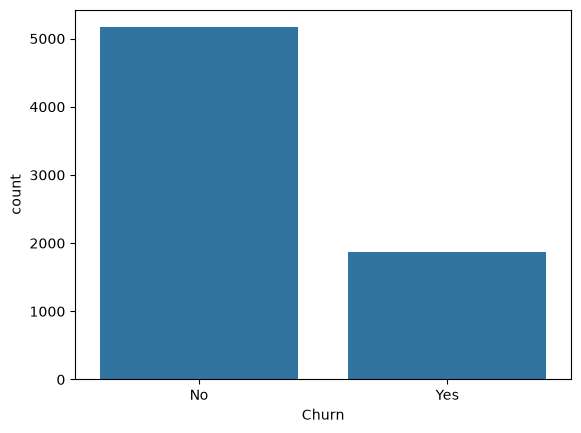

In [6]:
sns.countplot(data=df, x='Churn')
print(df['Churn'].value_counts())

<Axes: xlabel='Contract', ylabel='TotalCharges'>

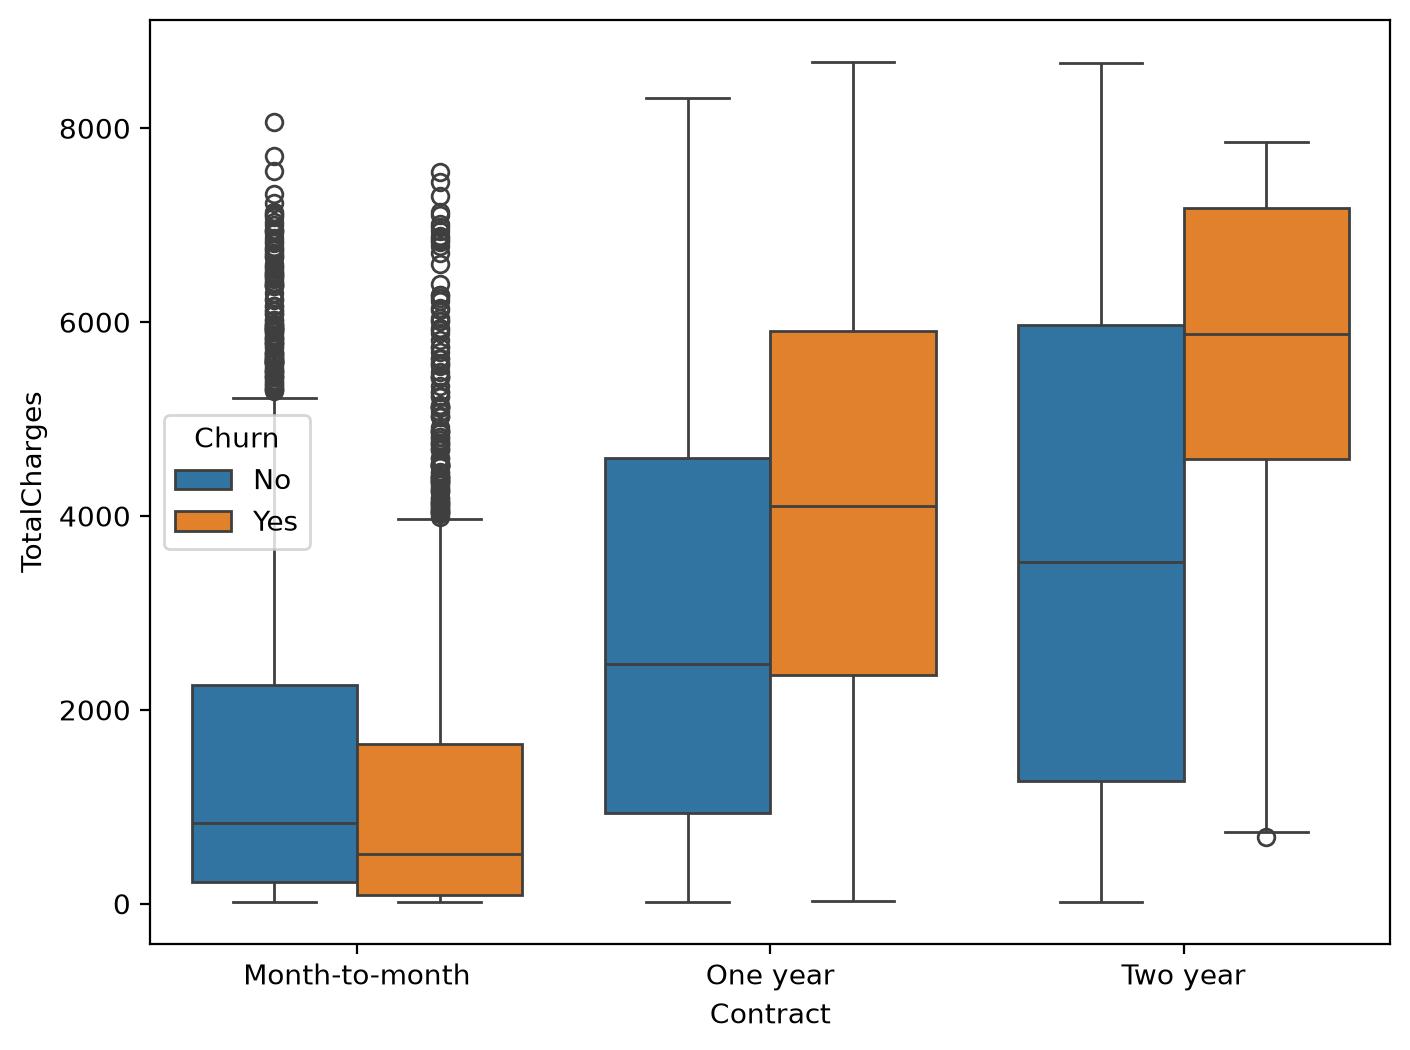

In [7]:
plt.figure(figsize=(8,6), dpi = 200)
sns.boxplot(data=df, y = 'TotalCharges', x= 'Contract', hue = 'Churn')

## Podemos ver que los clientes que tienen contratos mensuales son los que menos duran con sel servicio, pero son los que presentan más outliers. En los clientes con contratos de un año o dos años, la mediana de los clientes que hacen churn es mayor de los clientes leales. Sin embargo, si los clientes leales deciden hacer churn, tienden a ser los clientes que más dinero le dejan a la empresa. Si este cliente cancela, el impacto financiero (LTV perdido) para la empresa es masivo en comparación con un usuario mes a mes.

In [8]:
#Correlación entre columnas a que un cliente haga churn

corr_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']]).corr()

In [9]:
corr_df['Churn_Yes'].sort_values()

Churn_No                                  -1.000000
Contract_Two year                         -0.301552
DeviceProtection_No internet service      -0.227578
StreamingMovies_No internet service       -0.227578
StreamingTV_No internet service           -0.227578
InternetService_No                        -0.227578
TechSupport_No internet service           -0.227578
OnlineBackup_No internet service          -0.227578
OnlineSecurity_No internet service        -0.227578
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup

In [10]:
corr_yes_churn = corr_df['Churn_Yes'].sort_values().iloc[1:-1]


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, 'Contract_Two year'),
  Text(1, 0, 'DeviceProtection_No internet service'),
  Text(2, 0, 'StreamingMovies_No internet service'),
  Text(3, 0, 'StreamingTV_No internet service'),
  Text(4, 0, 'InternetService_No'),
  Text(5, 0, 'TechSupport_No internet service'),
  Text(6, 0, 'OnlineBackup_No internet service'),
  Text(7, 0, 'OnlineSecurity_No internet service'),
  Text(8, 0, 'PaperlessBilling_No'),
  Text(9, 0, 'Contract_One year'),
  Text(10, 0, 'OnlineSecurity_Yes'),
  Text(11, 0, 'TechSupport_Yes'),
  Text(12, 0, 'Dependents_Yes'),
  Text(13, 0, 'Partner_Yes'),
  Text(14, 0, 'PaymentMethod_Credit card (automatic)'),
  Text(15, 0, 'InternetService_DSL'),
  Text(16, 0, 'PaymentMethod_Bank transfer (automatic)'),
  Text(17, 0, 'Paymen

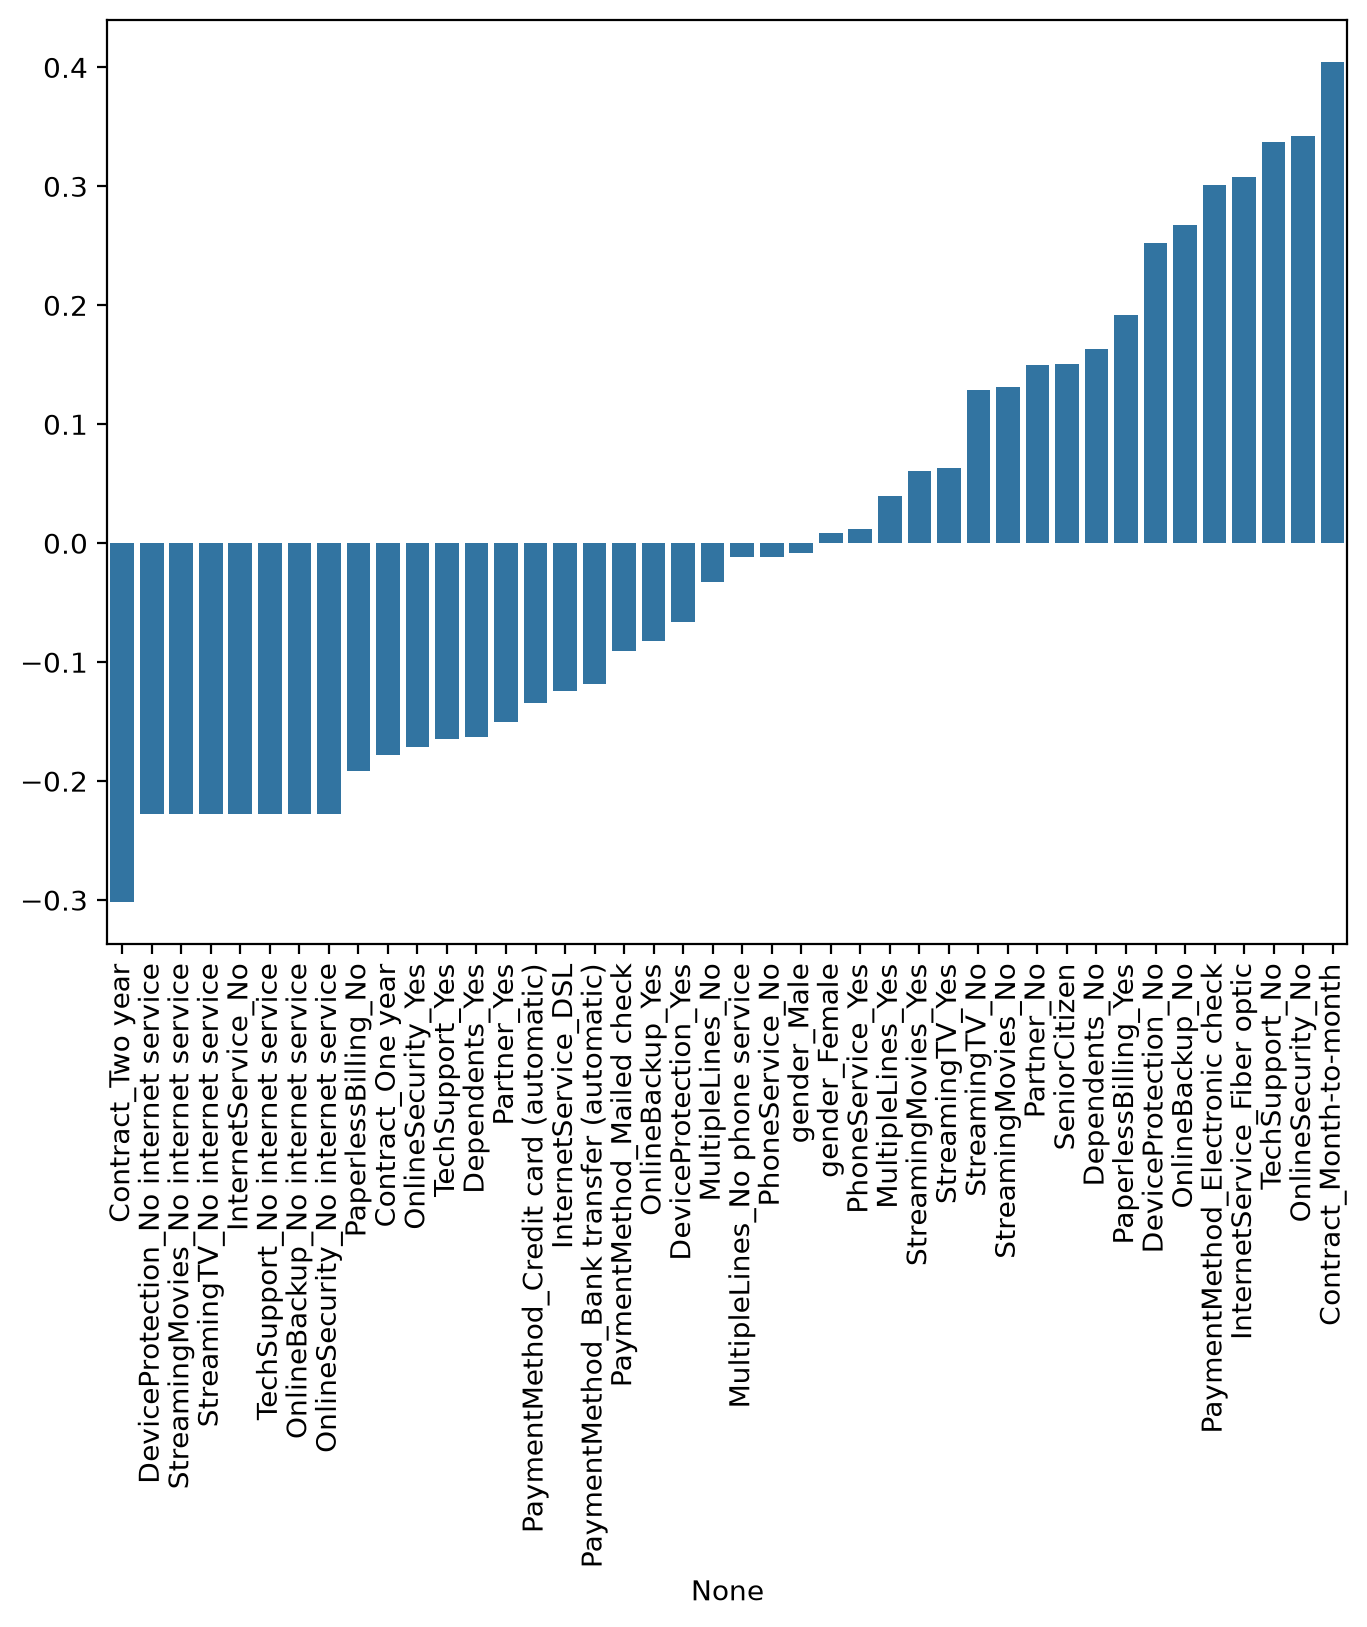

In [11]:
plt.figure(figsize=(8,6), dpi = 200)
sns.barplot(x = corr_yes_churn.index, y = corr_yes_churn.values)
plt.xticks(rotation = 90)

## El análisis de correlación lineal confirma que las variables contractuales y de soporte técnico dominan el comportamiento del Churn. Mientras que el contrato de Month-to-month y la ausencia de TechSupport actúan como los principales catalizadores de abandono, los contratos a Two year y los servicios adicionales de seguridad funcionan como fuertes anclajes de retención. Sorprendentemente, la fibra óptica presenta un riesgo de fuga elevado, lo que sugiere la necesidad de auditar la estabilidad de la red o la competitividad de sus tarifas.

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

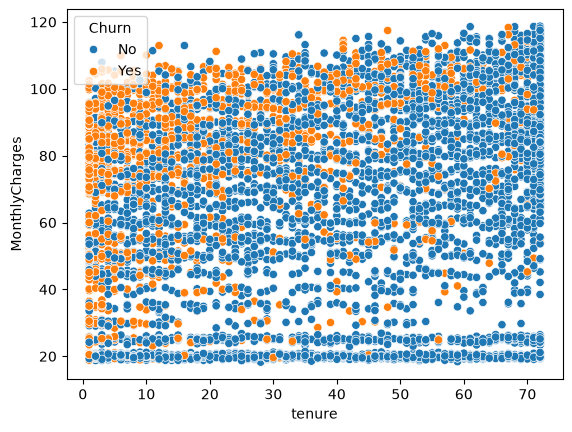

In [12]:
sns.scatterplot(data=df, x = 'tenure', y = 'MonthlyCharges', hue='Churn')

<Axes: xlabel='tenure', ylabel='Density'>

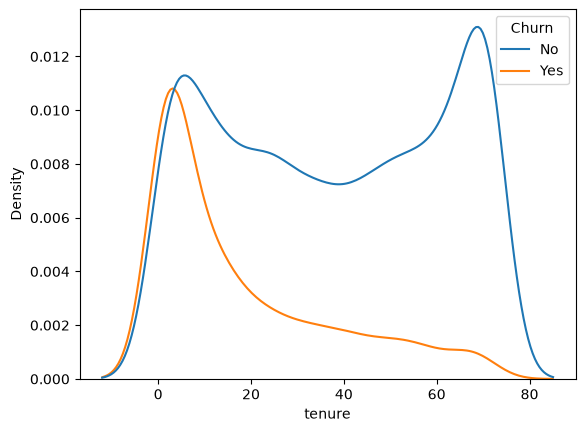

In [15]:
sns.kdeplot(data=df, x= 'tenure', hue = 'Churn')

In [16]:
df[df['Churn'] == 'Yes']['tenure'].median()

np.float64(10.0)

## Hipótesis 1: 
La probabilidad de Churn disminuye monótonamente a medida que aumenta la antigüedad del cliente en la plataforma.

## Insight Ejecutivo: 
Se detecta un comportamiento bimodal en la retención y un riesgo concentrado en etapas tempranas. El 50% del Churn total ocurre en clientes con menos de 10 meses de antigüedad. Se recomienda al equipo de Producto diseñar estrategias de acompañamiento durante los primeros 90 días del usuario.